Here is a concise synopsis of the **Customer-Segmentation-using-K-Means-Clustering** program:

### Core Function

The program uses machine learning to automatically group a business's customer base into distinct, actionable segments based on shared behaviors and demographics (specifically **Age**, **Annual Income**, and **Spending Score**). Instead of relying on human guesswork, it uncovers hidden patterns in transaction data to identify who your different customer groups are.

### How It Works (The Pipeline)

1. **Data Normalization:** It scales the data so that large numerical ranges (like a $100,000 salary) don't mathematically overwhelm smaller ranges (like an age of 25).
2. **K-Means Clustering:** It groups customers by minimizing the physical distance between data points in a geometric space, placing similar buyers close together.
3. **Mathematical Optimization:** It utilizes the **Elbow Method** to automatically find the mathematically ideal number of customer segments ($K$).
4. **Dimensionality Reduction (PCA):** It squashes the complex 3-D customer features down into a flat 2-D plot so developers and stakeholders can easily see the visual separation between groups.

### Business Value

The program concludes by translating raw clusters into real-world marketing personas. For example, it cleanly separates your high-value **"Target Premium VIPs"** (high income, high spend) from your **"Impulsive Buyers"** (low income, high spend). This allows marketing teams to design hyper-targeted ad campaigns, optimize product pricing, and improve customer retention strategies.

In [1]:
# ==========================================
# CELL 1: INITIALIZATION
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Apply global visual themes for Jupyter plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline 

print("✅ Environment initialized successfully.")

✅ Environment initialized successfully.


In [2]:
# ==========================================
# CELL 2: DATA LOADING
# ==========================================
print("🔄 Generating synthetic customer dataset...")
np.random.seed(42)

# Creating mathematical distinct customer distribution profiles
cluster_1 = np.random.multivariate_normal([25, 30000, 80], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
cluster_2 = np.random.multivariate_normal([45, 90000, 20], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
cluster_3 = np.random.multivariate_normal([35, 60000, 50], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
cluster_4 = np.random.multivariate_normal([55, 120000, 85], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)

# Stack arrays together and construct the dataframe
data = np.vstack([cluster_1, cluster_2, cluster_3, cluster_4])
df = pd.DataFrame(data, columns=['Age', 'Annual_Income', 'Spending_Score'])

# Clip boundaries to maintain highly realistic numbers
df['Age'] = df['Age'].astype(int).clip(18, 70)
df['Annual_Income'] = df['Annual_Income'].astype(int).clip(15000, 150000)
df['Spending_Score'] = df['Spending_Score'].astype(int).clip(1, 100)

# Preview the data directly in your Jupyter notebook output frame
df.head()

🔄 Generating synthetic customer dataset...


C:\Users\User\AppData\Local\Temp\ipykernel_13804\1236022178.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cluster_1 = np.random.multivariate_normal([25, 30000, 80], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
C:\Users\User\AppData\Local\Temp\ipykernel_13804\1236022178.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cluster_2 = np.random.multivariate_normal([45, 90000, 20], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
C:\Users\User\AppData\Local\Temp\ipykernel_13804\1236022178.py:10: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cluster_3 = np.random.multivariate_normal([35, 60000, 50], [[5, 500000, 5], [500000, 10000000, 10], [5, 10, 25]], 100)
C:\Users\User\AppData\Local\Temp\ipykernel_13804\1236022178.py:11: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cluster_4 = np.random.multivariate_normal([55, 120000, 85], [[5, 500000, 5], [500000, 10000000, 10], 

,Age,Annual_Income,Spending_Score
0,18,28428,83
1,18,25181,78
2,18,25012,77
3,18,28280,77
4,70,29219,71


In [3]:
# ==========================================
# CELL 3: PREPROCESSING
# ==========================================
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]

# Standardize values to a Mean of 0 and Standard Deviation of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled. Shape of target array:", X_scaled.shape)
print("Sample row layout:\n", X_scaled[:1])

✅ Features scaled. Shape of target array: (400, 3)
Sample row layout:
 [[-1.05176112 -1.3754002   0.91182323]]


🔄 Computing WCSS (Inertia) for K values 1 through 10...


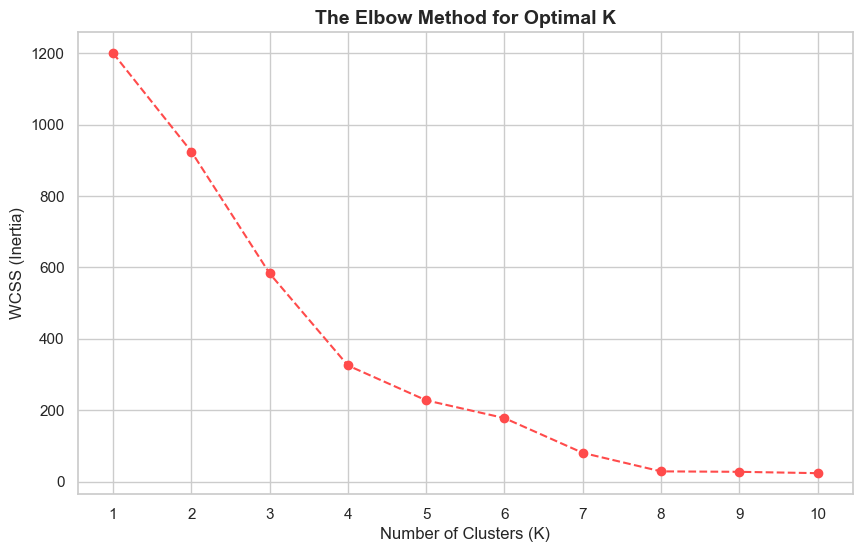

In [5]:
# ==========================================
# CELL 4: ELBOW METHOD OPTIMIZATION
# ==========================================
wcss = []
k_range = range(1, 11)

print("🔄 Computing WCSS (Inertia) for K values 1 through 10...")
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_test.fit(X_scaled)
    wcss.append(kmeans_test.inertia_)

# Render out the visualization graph
plt.figure()
plt.plot(k_range, wcss, marker='o', linestyle='--', color='#ff4b4b')
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

In [6]:
# ==========================================
# CELL 5: MODEL TRAINING
# ==========================================
# Choose your K value based on the bend observed in the cell 4 graph
optimal_k = 4
print(f"🔄 Instantiating and training K-Means with K={optimal_k}...")

final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
# Fit model and directly assign the resulting cluster numbers to our source dataframe
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# Calculate numeric clustering performance
sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"✅ Training completed.")
print(f"📊 Silhouette Separation Score: {sil_score:.3f} (Closer to 1.0 is better)")

🔄 Instantiating and training K-Means with K=4...
✅ Training completed.
📊 Silhouette Separation Score: 0.527 (Closer to 1.0 is better)


🔄 Transforming dimensions using PCA...


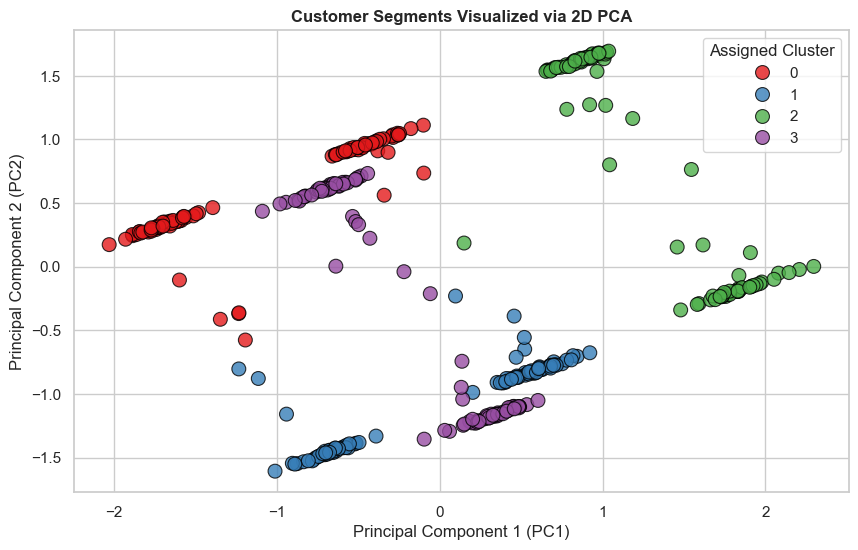

In [7]:
# ==========================================
# CELL 6: PCA VISUALIZATION
# ==========================================
print("🔄 Transforming dimensions using PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Package coordinates into a clean visualization-specific DataFrame
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Draw the 2D cluster maps
plt.figure()
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca, 
    palette='Set1', s=100, alpha=0.8, edgecolor='black'
)
plt.title('Customer Segments Visualized via 2D PCA', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Assigned Cluster')
plt.show()

In [8]:
# ==========================================
# CELL 7: STRATEGIC BUSINESS ANALYTICS
# ==========================================
# Group by assigned cluster tags and calculate column-specific averages
profile_analysis = df.groupby('Cluster')[features].mean()

# Practical real-world mapping profiles
persona_dictionary = {
    0: "Young, High Spending & Low Income (Impulsive)",
    1: "Older, High Income & Low Spending (Conservative)",
    2: "Middle-Aged, Moderate Income & Spending (Standard)",
    3: "Mature, Wealthy & High Spending (Target Premium VIP)"
}

profile_analysis['Target Customer Persona'] = profile_analysis.index.map(persona_dictionary)

# Format and display the strategic profiles matrix directly inside your cell output
profile_analysis

,Age,Annual_Income,Spending_Score,Target Customer Persona
Cluster,,,,
0,68.784314,78085.578431,32.862745,"Young, High Spending & Low Income (Impulsive)"
1,18.989691,71548.484536,36.546392,"Older, High Income & Low Spending (Conservative)"
2,46.000000,30011.732673,79.554455,"Middle-Aged, Moderate Income & Spending (Stand..."
3,42.750000,119755.260000,85.120000,"Mature, Wealthy & High Spending (Target Premiu..."
